# Week 8 - Evolutionary Multi-objective Optimisation

This week we talked about evolutionary multi-objective optimisation. So far we have considered comprising a single measure of fitness - a cost or a quality, for example. As we saw, problems often comprise multiple objectives. By following this notebook you will create a multi-objective genetic algorithm that solves another benchmark problem. Recall, that a benchmark problem is one for which we know the answer and can confirm when the optimiser converges to it. In this case, we are searching for the _Pareto front_, the best feasible trade-off between the objectives.

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In last week's exercise you saw two __benchmark__ problems, and you will recall that a benchmark problem is used to test an optimiser. This week we'll use a multi-objective benchmark, which provides a multi-objective optimiser a 2-objective problem it can be tested with (there are a plethora of such benchmarks, each with its own problem characteristics -- for example, allowing us to test how an algorithm scales to a large number of objectives.

In [185]:
def zdt5(x):
    """
    ZDT5 test problem.
    
    See: https://ieeexplore.ieee.org/abstract/document/6787994/ for more details.
    """
    # Get the number of decision variables and check that the number is valid.
    D = x.shape[0]
    assert D > 30, "You should have more than 30 decision variables"
    assert D % 5 == 0, "Number of decision variables should divide by 5"
    
    # Split into blocks
    blocks = [x[:30]] + [x[i:i+5] for i in range(30, D, 5)]

    f1 = 1 + blocks[0].sum()
    g = np.sum([2+b.sum() if b.sum() < 5 else 1 for b in blocks[1:]])
    f2 = g / f1
    return np.array([f1, f2])

## Comparing multi-objective solutions.
During the lecture we learned about the __dominance__ relation: a solution ___u___ dominates solution ___v___ if:
* ___u___ is no worse than ___v___ on any objective;
* ___u___ is better than ___v___ on at least one objective.

The first exercise requires you to create a function _dominates(u,v)_ that takes two solutions, returning true if _u_ dominates _v_ and false otherwise. Then you will use _dominates_ within a function called _ndsort_, which will produce a ranking of multi-objective solutions.

### Exercise 1

Create a function _dominates(u,v)_ that implements the Pareto dominance relation.

In [162]:
def dominates(u, v):
    """
    Pareto dominance relation. Assume (without loss of generality) that all
    objectives are to be minimised.
    """
    return all(u<=v) and any(u<v)

As with last week, we'll run some code to perform basic unit tests on our dominance function. To do this, I have defined three 3-objective objective vectors. I have ensured that one (_u2_) dominates the another (_u1_) -- and, therefore, that _u1_ does not dominate _u2_. There is a third objective vector (_u3_); its solution is mutually non-dominating with _u1_.

In [163]:
u1 = np.array([0.5, 0.7, 0.3])
u2 = np.array([0.3, 0.6, 0.2])
u3 = np.array([0.3, 0.7, 0.5])

assert dominates(u2, u1), "u2 should dominate u1"
assert not dominates(u1, u2), "u1 should not dominate u2"
assert not dominates(u1, u3) and not dominates(u3, u1), "u1 and u3 should be mutually non-dominating"

## Non-dominated sorting
Having implemented the dominance relation we're going to use it to implement the non-dominated sorting procedure we discussed during the lecture. Remember, this algorithm works by repeatedly peeling away layers of non-dominated solutions; each layer forms a rank, and its removal reveals a new set of non-dominated solutions. The resulting _partial ordering_ over the solutions provides a hierarchy of solution quality that a GA can use within its selection operator.

Here is the algorithm:

1. Initialise a counter to keep track of which rank we're on ($r$).
2. Identify the non-dominated solutions.
3. Assign the non-dominated solutions to rank $r$.
4. Temporarily discard the non-dominated solutions from the population.
5. Increment $r$.
6. If solutions remain, return to (1).

Keep in mind that we still want to use the solutions, so _temporarily discard_ shouldn't mean "delete forever"! I generally make a copy of the population to do this, so that I'm not working on the real solutions.

### Exercise 2
Implement non-dominating sorting using the dominance relation, within the skeleton _ndsort_ function provided.

In [173]:
def ndsort(Y):
    """
    Parameters:
     - Y: The population to be sorted.
    """
    N = Y.shape[0]      # N: number of solutions.

    # Initialise a vector in which to store the ranks.    
    ranks = np.zeros(N, dtype=int)

    # Initialise a list of indices - we need to keep track of which solution
    # is which as we temporarily discard them.
    indices = np.arange(N)

    # Initialise the current rank.
    rank = 0

    while indices.size > 0:
        # Move to the next rank.
        rank += 1

        # Initialise a list in which to store the current non-dominated solutions.
        current_front = []

        for i in range(indices.size):
            dominated = False
            for j in range(indices.size):
                if i != j and dominates(Y[indices[j]], Y[indices[i]]):
                    dominated = True
                    break
            if not dominated:
                current_front.append(i)

        # Assign ranks to current front
        for i in sorted(current_front, reverse=True):
            ranks[indices[i]] = rank
            indices = np.delete(indices, i)

    return ranks


We need to test the _ndsort_ function. You can do this visually -- sample 1,000 or so 2D points, uniformly distributed. These will stand in for your objective vectors. Pass the array of samples to _ndsort_, and then produce a scatter plot of the samples. Colour them according to their non-dominated rank.

You can pass the array of ranks to Matplotlib to use as the colours (you need to also specify a colourmap - viridis is a good one, its accessible to a wide audience. Use the following code:

`plt.scatter(samples[:,0], samples[:,1], c=ndranks, cmap="viridis")`

Where:
 * `samples` is the 2D array of uniform random samples;
 * `ndranks` is the 1D array containing the non-dominated rank of each of your samples.

You are looking for a scatterplot of points roughly organised as a square; the colour should progress from dark blue in the lower left-hand corner to yellow in the top right-hand corner (unless you've used a different colourmap -- if so, naturally the colours will differ!).

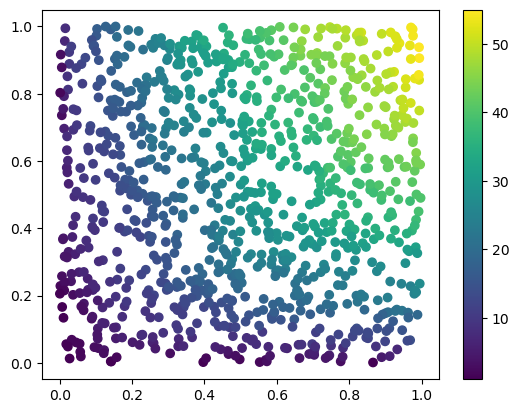

In [165]:
samples = np.random.rand(1000,2)
ndranks = ndsort(samples)
c = cols[ndranks]
plt.scatter(samples[:,0], samples[:,1], c=ndranks, cmap="viridis")
plt.colorbar()

## Crowding distance

Crowding distance is a measure of the diversity of solutions in a non-dominated set. Recall the algorithm from the lecture:

1. $N=|\mathbf{Y}|$
2. __for__ $i=1,\ldots,N$ __do__
    1. $d_i=0$
3. __end for__
4. __for__ $m=1,\ldots,M$ __do__
    1. $\mathbf{Y} = $_sort_($\mathbf{Y}$)
    2. $d_1 = d_N = \infty$
    3. __for__ $i=2,\ldots,(N-1)$ __do__
        1. $d_i = d_i + \left(\mathbf{Y}^m_{i+1} - \mathbf{Y}^m_{i-1}\right) / \left(f^\max_m - f^\min_m\right)$
    4. __end for__
6. __end for__

Implement a function called _cdist_ that computes the crowding distance of each solution.

### Exercise 3
Implement a crowding distance function.

In [166]:
def cdist(Y):
    """
    Computes the crowding distance of the mutually non-dominating solutions
    in Y.

    Note, this version only works in two objectives.
    """
    N, M = Y.shape            # Number of solutions/objectives.

    # Initialise an array of distances and set the distances of the extreme
    # solutions to be infinity.
    distances = np.zeros(N)

    for m in range(M):
        # Sort according to objective m.
        I = np.argsort(Y[:,m])
        Yp = Y[I,:]
        distances[I[0]], distances[I[-1]] = np.inf, np.inf

        limits = np.array([Yp[:,m].min(), Yp[:,m].max()])

        for i in range(1,N-1):
            distances[I[i]] += (Yp[i+1,m]-Yp[i-1,m])/limits.ptp()

    return distances

Test the crowding distance as you tested the non-dominated sorting code - by passing some solutions through it and visualising the results. Use the same set of points you used in that code, extract the non-dominated solutions, and plot them coloured according to the crowding distance.

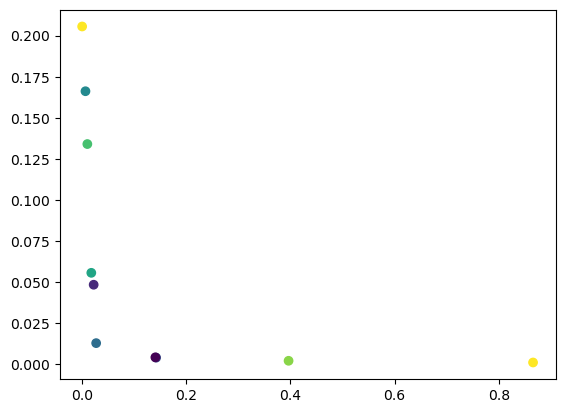

In [167]:
# Using the samples used to test exercise 3, extract the non-dominated solutions.
I = np.nonzero(ndranks == 1)[0]
Z = samples[I,:]

# Compute their crowding distances.
distances = cdist(Z)

# Plot the solutions and colour according to their crowding distance. You can
# use this plot to confirm that those furthest away from nearest neighbours have
# the greatest crowding distance.
ranks = st.rankdata(distances)
plt.scatter(Z[:,0], Z[:,1], c=ranks, cmap="viridis")

## Multi-objective Genetic Algorithm

Having implemented the multi-objective parts, you can now implement the GA. You will need crossover, mutation, and selection objects.

### Exercise 4

Implement the following functions:

 * _mutation(x)_, which takes a single solution and performs a bit flip operation on exactly one of the decision variables.
 * _crossover(x1, x2)_, which takes two parents, identifies a crossover point, and exchanges the decision variables before the crossover point between _x1_ and _x2_.

In [168]:
def mutation(x):
    """
    Mutation operator.
    """
    idx = np.random.randint(x.shape[0])
    xp = x.copy()
    xp[idx] = abs(1-xp[0])
    return xp
    


def crossover(x1, x2):
    """
    Crossover operator.
    """
    idx = np.random.randint(x1.shape[0])
    return np.concatenate((x1[:idx], x2[idx:]))

### Exercise 5

Implement a selection operator (_selection(Zx,Zy)_). It takes the combined parent and child population (_Zx_) and the corresponding combined objective vectors (_Zy_). You should use non-dominated sorting and crowding distance to select the parent population for the next generation.

In [169]:
def selection(Zx, Zy):
    """
    Based on the combined parent and child populations X, and their
    corresponding combined objective vectors Y, undertake non-dominated
    sorting and crowding distance to identify the parent solutions for
    the next generation.
    """
    # Compute a non-dominated sort of the combined parent and child populations.
    ranks = ndsort(Zy)

    N = Zx.shape[0] // 2

    parents = []
    rank = 0

    while len(parents) < N:
        rank += 1

        I = np.nonzero(ranks == rank)[0]
        if len(parents) + I.shape[0] <= N:
            parents = parents + I.tolist()
        else:
            distances = cdist(Zy[I,:])
            J = np.argsort(-distances)
            parents = parents + I[J[:N-len(parents)]].tolist()

    parents = np.array(parents)
    return Zx[parents,:], Zy[parents,:]
            
            

### Exercise 6

Implement a MOGA to optimise ZDT5 using the operators you implemented in the earlier exercises.

In [170]:
def ga(ngens, problem, popsize, ndims):
    """

    """
    # Initialise the population.
    X = np.random.randint(0, 2, (popsize, ndims))
    Y = np.array([problem(X[i,:]) for i in range(popsize)])

    # Evolve a population of solutions.
    for g in range(ngens):
        Xp = np.zeros_like(X)
        Yp = np.zeros_like(Y)
        
        for i in range(popsize):
            # Generate two solutions at random and apply crossover. Then apply mutation
            # and evaluate the new child solution.
            idx, jdx = np.random.permutation(ndims)[:2]
            Xp[i] = crossover(X[idx], X[jdx])
            Xp[i] = mutation(Xp[i])
            Yp[i] = problem(Xp[i])

        # Combine the parent and child populations.
        Zx = np.concatenate((X, Xp), axis=0)
        Zy = np.concatenate((Y, Yp), axis=0)

        # Compute a non-dominated sort of the combined parent and child populations.
        #ranks = ndsort(Zy)

        # Identify the solutions to retain.
        X, Y = selection(Zx, Zy)
    
    # Return the final populations.
    return X, Y

### Exercise 7

Produce a plot of the 2-objective Pareto front.

Text(0, 0.5, '$f_2$')

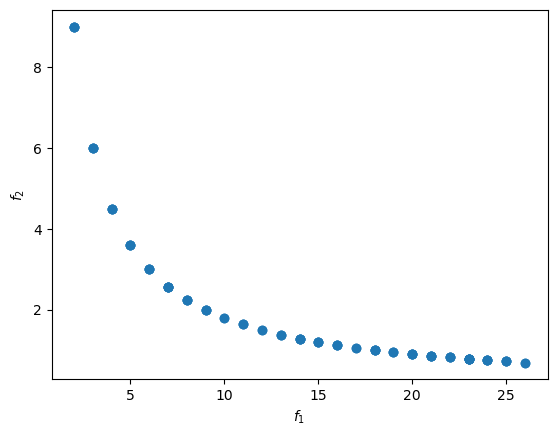

In [188]:
X, Y = ga(100, zdt5, 100, 85)
plt.scatter(Y[:,0], Y[:,1])
plt.xlabel("$f_1$")
plt.ylabel("$f_2$")